# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
#Завантаження даних
df = pd.read_csv('House_Rent_Dataset.csv', sep=None, engine='python')

#Розмір датасету
df.shape

(4746, 12)

In [3]:
#Перші 5 рядків
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
#Загальна інформація про датасет
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [5]:
#Наявність пропущенних значень
missing_data = df.isnull().sum()
missing_data

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [6]:
#Відсоток пропущенних значень
missing_percent = (missing_data / len(df)) * 100
missing_percent

,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


In [7]:
#Статистичні дані (для числових змінних)
stats = df[['Rent', 'Size']].describe()
stats.round(2)

,Rent,Size
count,4746.00,4746.00
mean,34993.45,967.49
std,78106.41,634.20
min,1200.00,10.00
25%,10000.00,550.00
50%,16000.00,850.00
75%,33000.00,1200.00
max,3500000.00,8000.00


In [8]:
#Копія Rent
df_rent = df['Rent'].copy()

#Гістограма розподілу цільової змінної (Rent)
fig_hist = px.histogram(
    df_rent,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (Rent)',
    labels={'Rent': 'Кількість оренд', 'count': 'Сума оренди'}
)
fig_hist.update_layout(
    showlegend=False,
    height=400
)
fig_hist.show()

In [9]:
#Перший та третій квартилі
Q1 = df_rent.quantile(0.25)
Q3 = df_rent.quantile(0.75)

#Міжквартильний діапазон (IQR)
IQR = Q3 - Q1

#Межі
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Перший квартиль (rent): Q1 = {Q1}")
print(f"Третій квартиль (rent): Q3 = {Q3}")
print(f"Міжквартильний діапазон (rent): IQR = {IQR}")
print(f"Межі для нормальних значень: від {lower_bound} до {upper_bound}")

Перший квартиль (rent): Q1 = 10000.0
Третій квартиль (rent): Q3 = 33000.0
Міжквартильний діапазон (rent): IQR = 23000.0
Межі для нормальних значень: від -24500.0 до 67500.0


In [10]:
#Пошук викидів
outliers = df_rent[(df_rent < lower_bound) | (df_rent > upper_bound)]

print(f"Кількість знайдених викидів: {len(outliers)}")

#Видалення викидів (залишились дані в межах [lower, upper])
df_rent_clean = df_rent[(df_rent >= lower_bound) & (df_rent <= upper_bound)].copy()

Кількість знайдених викидів: 520


In [11]:
#Кількість унікальних значень для кожної з категоріальних колонок (аналіз категоріальних змінних)
df.nunique()

,0
Posted On,81
BHK,6
Rent,243
Size,615
Floor,480
Area Type,3
Area Locality,2235
City,6
Furnishing Status,3
Tenant Preferred,3



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [12]:
#Датафрейм тільки з числовими метриками
df_metrics = df[['Rent', 'Size']].dropna()

#Матриця кореляцій
correlation_matrix = df_metrics.corr()
correlation_matrix

,Rent,Size
Rent,1.000000,0.413551
Size,0.413551,1.000000


In [13]:
#Heatmap кореляційної матриці
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='PiYG',
    title='Кореляційна матриця',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [14]:
#Scatter plot між Size та Rent
fig_scat = px.scatter(
                 df_metrics,
                 x='Size',
                 y='Rent',
                 hover_data=['Size', 'Rent'],
                 title='Size vs Rent',
                 labels={'Size': 'Площа житла', 'Rent': 'Орендна плата'}
                 )
fig_scat.update_layout(height=600)
fig_scat.show()

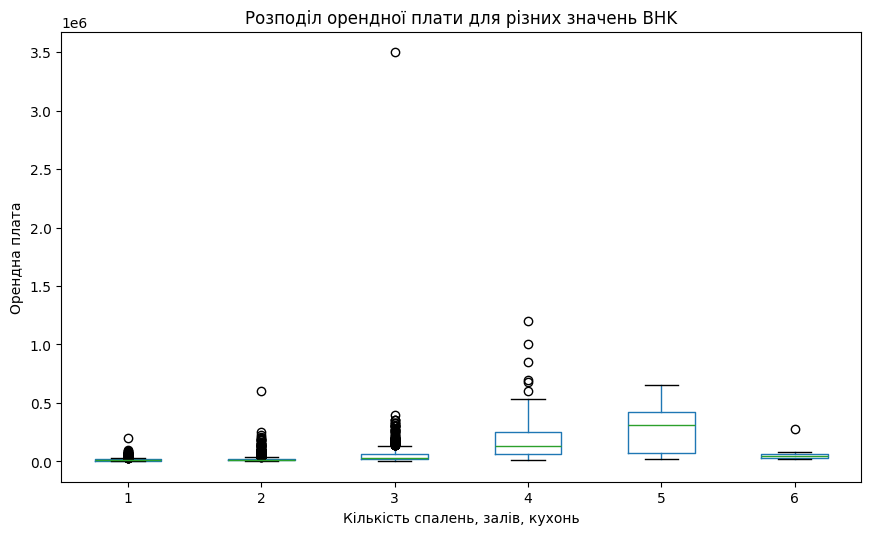

In [15]:
#Boxplot взаємозв'язкку між BHK та Rent (який розподіл плати для різних значень BHK)
fig_box = df.boxplot(
    column='Rent',
    by='BHK',
    figsize=(10, 6),
    grid = False
)
plt.title('Розподіл орендної плати для різних значень BHK')
plt.suptitle('')
plt.ylabel('Орендна плата')
plt.xlabel('Кількість спалень, залів, кухонь')
plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [16]:
#Кількість різних значень
df['Area Type'].nunique(), df['City'].nunique(), df['Furnishing Status'].nunique(), df['Tenant Preferred'].nunique()

(3, 6, 3, 3)

In [17]:
#One-Hot Encoding для Area Type
area_type_dummies = pd.get_dummies(df['Area Type'])
area_type_dummies.head().astype(int)
#area_type_dummies.head()

,Built Area,Carpet Area,Super Area
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,1,0


In [18]:
#One-Hot Encoding для City
city_dummies = pd.get_dummies(df['City'])
city_dummies.head().astype(int)
#city_dummies.head()

,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,0,0,1,0


In [19]:
#One-Hot Encoding для Furnishing Status
furnishing_status_dummies = pd.get_dummies(df['Furnishing Status'])
furnishing_status_dummies.head().astype(int)
#furnishing_status_dummies.head()

,Furnished,Semi-Furnished,Unfurnished
0,0,0,1
1,0,1,0
2,0,1,0
3,0,0,1
4,0,0,1


In [20]:
#One-Hot Encoding для Tenant Preferred
tenant_preferred_dummies = pd.get_dummies(df['Tenant Preferred'])
tenant_preferred_dummies.head().astype(int)
#tenant_preferred_dummies.head()

,Bachelors,Bachelors/Family,Family
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,1,0,0


In [21]:
#Додавання до основного датафрейму
df_new = pd.concat([df, area_type_dummies, city_dummies, furnishing_status_dummies, tenant_preferred_dummies], axis=1)
df_new.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,...,Delhi,Hyderabad,Kolkata,Mumbai,Furnished,Semi-Furnished,Unfurnished,Bachelors,Bachelors/Family,Family
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,...,False,False,True,False,False,False,True,False,True,False
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,...,False,False,True,False,False,True,False,False,True,False
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,...,False,False,True,False,False,True,False,False,True,False
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,...,False,False,True,False,False,False,True,False,True,False
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,...,False,False,True,False,False,False,True,True,False,False


In [22]:
df_new.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact', 'Built Area', 'Carpet Area',
       'Super Area', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata',
       'Mumbai', 'Furnished', 'Semi-Furnished', 'Unfurnished', 'Bachelors',
       'Bachelors/Family', 'Family'],
      dtype='object')

In [23]:
#Набір колонок для моделювання
features = (
    area_type_dummies.columns.tolist() +
    city_dummies.columns.tolist() +
    furnishing_status_dummies.columns.tolist() +
    tenant_preferred_dummies.columns.tolist()
)

#Визначення X (ознаки) та y (ціль)
X = df_new[features]  # Ознаки
y = df_new['Rent']  # Цільова змінна

print(f"Розмір X (ознак): {X.shape}")
print(f"Розмір y (цілі): {y.shape}")

Розмір X (ознак): (4746, 15)
Розмір y (цілі): (4746,)


In [24]:
from sklearn.preprocessing import StandardScaler

#Створення та застосування скейлера
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Перетворення назад у DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_scaled_df.head()

,Built Area,Carpet Area,Super Area,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai,Furnished,Semi-Furnished,Unfurnished,Bachelors,Bachelors/Family,Family
0,-0.020533,-0.968878,0.969696,-0.479097,-0.480758,-0.38223,-0.473103,2.83853,-0.507495,-0.408951,-0.949844,1.270778,-0.460381,0.614857,-0.332318
1,-0.020533,-0.968878,0.969696,-0.479097,-0.480758,-0.38223,-0.473103,2.83853,-0.507495,-0.408951,1.052804,-0.786920,-0.460381,0.614857,-0.332318
2,-0.020533,-0.968878,0.969696,-0.479097,-0.480758,-0.38223,-0.473103,2.83853,-0.507495,-0.408951,1.052804,-0.786920,-0.460381,0.614857,-0.332318
3,-0.020533,-0.968878,0.969696,-0.479097,-0.480758,-0.38223,-0.473103,2.83853,-0.507495,-0.408951,-0.949844,1.270778,-0.460381,0.614857,-0.332318
4,-0.020533,1.032121,-1.031251,-0.479097,-0.480758,-0.38223,-0.473103,2.83853,-0.507495,-0.408951,-0.949844,1.270778,2.172112,-1.626395,-0.332318


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [25]:
from sklearn.model_selection import train_test_split

#Поділ даних: 80% на навчання, 20% на тест
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,  # 20% даних йде на тест
    random_state=42  # фіксуємо випадковість для відтворюваності
)

In [26]:
from sklearn.linear_model import LinearRegression

#Створення моделі
model = LinearRegression()

#Навчння моделі на навчальних даних
model.fit(X_train, y_train)

LinearRegression()

In [27]:
#Виведення ваги для кожної ознаки
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

Built Area: -296.88
Carpet Area: 3723.78
Super Area: -3711.49
Bangalore: -3554.56
Chennai: -3931.90
Delhi: -2350.15
Hyderabad: -3870.84
Kolkata: -6335.50
Mumbai: 17807.03
Furnished: 4440.31
Semi-Furnished: 1894.47
Unfurnished: -5147.69
Bachelors: 1909.45
Bachelors/Family: -1213.93
Family: -613.86

Зміщення (intercept): 35207.98


Найбільше впливають на прогноз: місто, де знаходиться квартира та меблювання квартири. Оскільки вийшли аномально великі ваги для цих ознак, то можна зробити висновок, що модель не добре вивчила закономірності.

In [28]:
#Прогнози на тренувальній вибірці
y_train_pred = model.predict(X_train)

#Прогнози на тестовій вибірці (нові дані)
y_test_pred = model.predict(X_test)

#Порівняння перших 10 прогнозів з реальністю
comparison = pd.DataFrame({
    'Реальна орендна плата': y_test.values[:10],
    'Прогнозована орендна плата': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})

print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна орендна плата  Прогнозована орендна плата   Помилка
0                  16000                      6824.0    9176.0
1                  12000                     29144.0  -17144.0
2                  28000                     89336.0  -61336.0
3                   8000                     23778.0  -15778.0
4                  46000                     21481.0   24519.0
5                  17000                     35198.0  -18198.0
6                  57000                    105963.0  -48963.0
7                   9500                     21211.0  -11711.0
8                 400000                     98216.0  301784.0
9                  15000                     20264.0   -5264.0


Модель є не надто точною.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Розраховуємо метрики для тестової вибірки
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("Метрики якості моделі на тестовій вибірці:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

# Порівняння з навчальною вибіркою
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("\nМетрики якості моделі на навчальній вибірці:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2_train:.3f}")

Метрики якості моделі на тестовій вибірці:
MAE: 24878.22
RMSE: 56431.07
R²: 0.201

Метрики якості моделі на навчальній вибірці:
MAE: 25116.17
RMSE: 76271.83
R²: 0.122


In [30]:
np.mean(y_train)

np.float64(35151.516332982086)

Оскільки R² на навчальній вибірці нижчий ніж на тестовій вибірці - перенавчання моделі не спостерігаємо. Але оскільки R² і для навчальної вибірки, і для тестової вибірки все ж таки ближче до 0, ніж до 1, то модель недонавчилася.

In [31]:
# Візуалізація: реальні vs прогнозовані значення
fig_scat_test = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальні vs Прогнозовані значення (тестова вибірка)',
    labels={'x': 'Реальні значення', 'y': 'Прогнозовані значення'},
    opacity=0.6
)

# Додаємо ідеальну лінію (де прогноз = реальність)
max_val = max(y_test.max(), y_test_pred.max())
fig_scat_test.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig_scat_test.update_layout(height=500)
fig_scat_test.show()

Зважаючи на скупчення та розкид точок вище лінії - модель переоцінює орендну плату. Хоча, зважаючи на наявність групи точок нижче лінії, є квартири, для яких модель недооцінює орендну плату.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [32]:
#Обчислення помилок (residuals = реальні - прогнозовані значення)
residuals = y_test - y_test_pred
residuals.head()

,Rent
1566,9175.623265
3159,-17143.884564
538,-61335.836885
2630,-15777.633433
4418,24519.167103


In [33]:
#Гістограма розподілу помилок
fig_hist_er = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig_hist_er.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig_hist_er.update_layout(height=400)
fig_hist_er.show()

Середня помилка близька до 0 — модель не має систематичної похибки. Даний розподіл є не дуже симетричним — модель часто завищує орендну плату, але є квартири, для яких навпаки занижує орендну плату. Є одне велике відхилення (>1M) — модель сильно помилилася у визначенні орендної плати для деякої, досить малої, групи квартир (сильно занизила орендну плату).

In [34]:
#Scatter plot помилок відносно величини прогнозованих значень: помилки vs прогнозовані значення
fig_scat_er = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованих значень',
    labels={'x': 'Прогнозовані значення', 'y': 'Помилка'},
    opacity=0.5
)

#Горизонтальна лінія на 0 (без помилки)
fig_scat_er.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")
fig_scat_er.update_layout(height=400)
fig_scat_er.show()

Бачимо систематичні розкиди вздовж усієї осі прогнозованих значень - модель щось систематично не враховує. Для малих сум орендної плати модель прогнозує досить близькі до реальних суми орендної плати. Але чим більша орендна плата, тим більша помилка в прогнозі. Враховуючи більші скупчення від'ємних помилок - модель схильна завищувати прогнозовану орендну плату. Проте спостерігаються групи квартир, для яких навпаки, прогнозована орендна плата значно нижча від реальної.

In [35]:
#Прогнози з найбільшими помилками
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(residuals)
})

#Топ-5 найбільших помилок
top_errors = errors_df.nlargest(5, 'error')
print("Прогнози з найбільшими помилками прогнозування:")
print(top_errors)

Прогнози з найбільшими помилками прогнозування:
         real     predicted         error
1001  1200000  89335.836885  1.110664e+06
4457   400000  35197.669164  3.648023e+05
1718   380000  43835.856073  3.361641e+05
1344   400000  98215.556175  3.017844e+05
3148   330000  35141.956946  2.948580e+05


In [36]:
X_test.loc[1001]

,1001
Built Area,-0.020533
Carpet Area,1.032121
Super Area,-1.031251
Bangalore,-0.479097
Chennai,-0.480758
Delhi,-0.382230
Hyderabad,-0.473103
Kolkata,-0.352295
Mumbai,1.970461
Furnished,-0.408951


In [37]:
X_test.loc[4457]

,4457
Built Area,-0.020533
Carpet Area,1.032121
Super Area,-1.031251
Bangalore,-0.479097
Chennai,-0.480758
Delhi,-0.382230
Hyderabad,2.113703
Kolkata,-0.352295
Mumbai,-0.507495
Furnished,-0.408951


In [38]:
X_test.loc[1718]

,1718
Built Area,-0.020533
Carpet Area,1.032121
Super Area,-1.031251
Bangalore,2.087261
Chennai,-0.480758
Delhi,-0.382230
Hyderabad,-0.473103
Kolkata,-0.352295
Mumbai,-0.507495
Furnished,-0.408951


Великий вплив на помилку має місто, де знаходиться квартира. Також, омеблювана квартира чи ні.

Щоб поліпшити якість моделі, можна: змінити модель на сильнішу; додати нові ознаки; розділити датасет на декілька груп, наприклад, за площею квартири.